In [1]:
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import torch
import numpy as np
import pickle

from flonacomldft.utils.io_utils import load_pickle_file, load_csv_file, get_project_path
from flonacomldft.sampling import run_metropolis
from flonacomldft.utils.diagnostics import get_ESS
from flonacomldft.models.mixture import Mixture, get_models
from flonacomldft.internal_coordinates import Coordinates_mapping, join_data

# from flonacomldft.train_flow_from_data import get_ratio_acc
from flonacomldft.free_energy_computations import (
    compute_TFP_logratio, compute_deepBAR_logratio,
    compute_TFP, compute_BAR
)

def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


In [2]:
coord_mapping = Coordinates_mapping() 
T = 300
kb = 8.617333262e-5

/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning:

In [16]:
project_path = get_project_path()
isms_folders = ['results_adaptive_is0_25072550/adaptive_sampling_is0_25072550.pkl', 
                'results_adaptive_is1_25072551/adaptive_sampling_is1_25072551.pkl']
# get_project_path()
mlps_files = ['results_mlp_is0_25684204/is0_mlp_dic_training_25684204.pkl',
                'results_mlp_is1_256842010/is1_mlp_dic_training_256842010.pkl',]

## 1. Examinig the MCMC chains of the adaptive training

In [4]:
dict_results_adaptive = []
for flm in isms_folders:
    dict_results_adaptive.append(load_pickle_file(flm, path=project_path))

In [5]:
dict_results_adaptive[0].keys()

dict_keys(['dict_flows_training', 'mcmc_runs', 'xs', 'us', 'accs', 'isomers', 'time_flow', 'time_adaptive', 'args'])

In [6]:
print('size of one "xs" element of mcmc_runs:', dict_results_adaptive[0]['mcmc_runs'][0]['xs'].shape)
print('keys of one mcmc_run', dict_results_adaptive[0]['mcmc_runs'][0].keys())
print('Number of mcmc runs', len(dict_results_adaptive[0]['mcmc_runs']))
print('Number of "xs" directly in the result dictionnary', len(dict_results_adaptive[0]['xs']))
print('Size of these "xs"', dict_results_adaptive[0]['xs'][0].shape)

size of one "xs" element of mcmc_runs: torch.Size([20, 50, 12])
keys of one mcmc_run dict_keys(['xs', 'us', 'accs', 'isomers', 'time_mcmc', 'inds_dft', 'xs_dft', 'us_dft', 'isomers_dft'])
Number of mcmc runs 30
Number of "xs" directly in the result dictionnary 30
Size of these "xs" torch.Size([20, 50, 12])


Here there seems to be some repeated data in the saved files, might be good to avoid the repetitions. 

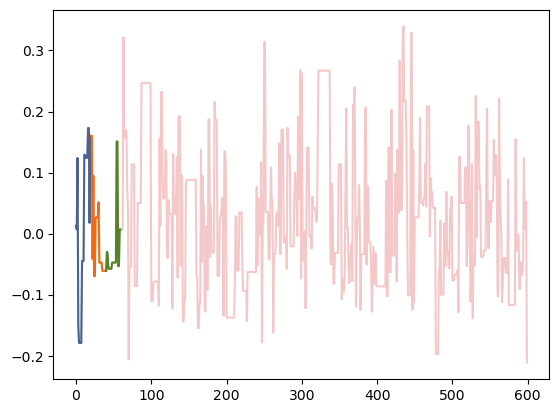

In [7]:
## Checking that the reshaping actually yields one chain
xs = torch.stack(dict_results_adaptive[0]['xs'])
plt.plot(xs[0][:,0,0].detach().numpy())
plt.plot(np.arange(20,40), xs[1][:,0,0].detach().numpy())
plt.plot(np.arange(40,60), xs[2][:,0,0].detach().numpy())

xs = torch.reshape(xs, (-1, 50, 12))
plt.plot(xs[:, 0, 0].detach().numpy(), alpha=0.25)


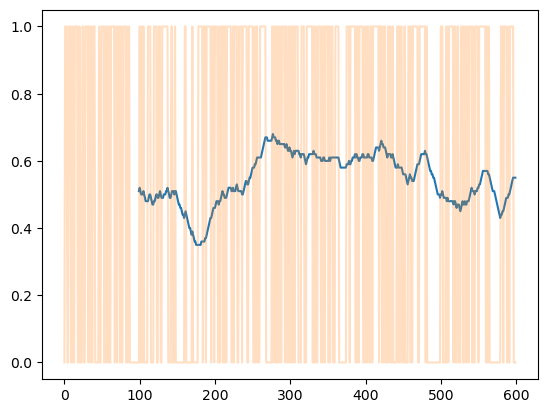

In [8]:
# Checking that there is no long rejection streaks
isomer_id = 1
accs = dict_results_adaptive[isomer_id]['accs']
len(accs)
accs = torch.stack(accs)
accs = torch.reshape(accs, (-1, 50))
chain_idx = 12
w=100
maxi=len(accs[:,chain_idx])
plt.plot(np.arange(w-1, maxi), moving_average(accs[:maxi,chain_idx], w))
plt.plot(accs[:maxi,chain_idx], alpha=0.25)

### 1.b Computing the Rhat convergence criteria

In [9]:
import arviz as az
from arviz.utils import get_coords, _var_names

In [10]:
## Load data as arviz InferenceData class
isomer_id = 0
xs_np = torch.stack(dict_results_adaptive[isomer_id]['xs']).reshape(-1, 50, 12).detach().numpy()
xs_np = xs_np.transpose(1, 0, 2)

burn_in = 100

idata = az.convert_to_inference_data(xs_np[:, burn_in:, :])
coords = {}
data = get_coords(az.convert_to_dataset(idata, group="posterior"), coords)
var_names = None
filter_vars = None

var_names = _var_names(var_names, data, filter_vars)
n_draws = data.dims["draw"]
n_samples = n_draws * data.dims["chain"]
first_draw = data.draw.values[0] # int of where where things should start
labels = ['x{:d}'.format(i) for i in range(12)]


In [11]:
data

<xarray.Dataset>
Dimensions:  (chain: 50, draw: 500, x_dim_0: 12)
Coordinates:
  * chain    (chain) int64 0 1 2 3 4 5 6 7 8 9 ... 40 41 42 43 44 45 46 47 48 49
  * draw     (draw) int64 0 1 2 3 4 5 6 7 8 ... 492 493 494 495 496 497 498 499
  * x_dim_0  (x_dim_0) int64 0 1 2 3 4 5 6 7 8 9 10 11
Data variables:
    x        (chain, draw, x_dim_0) float32 -0.1105 -0.08791 ... 1.537 1.248
Attributes:
    created_at:     2023-08-11T07:29:23.228320
    arviz_version:  0.16.0

/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/arviz/utils.py:185: NumbaDeprecationWarning: The keyword argument 'nopython=False' was supplied. From Numba 0.59.0 the default is being changed to True and use of 'nopython=False' will raise a warning as the argument will have no effect. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


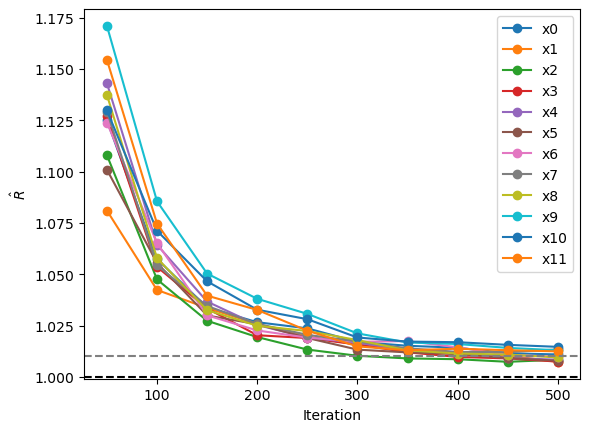

In [12]:
## Compute where to split the data to diagnostic the convergence
n_split = 10
xdata = np.linspace(n_samples / n_split, n_samples, n_split)
draw_divisions = np.linspace(n_draws // n_split, n_draws, n_split, dtype=int)

rhat_s = np.stack([np.array(az.rhat(data.sel(draw=slice(first_draw + draw_div)),
                    var_names=var_names,
                    method="rank",
                )['x'])
        for draw_div in draw_divisions
        ])

plt.figure()
plt.plot(draw_divisions, rhat_s, '-o',  label=labels)
plt.axhline(1, c='k', ls='--')
plt.axhline(1.01, c='grey', ls='--')
plt.xlabel('Iteration')
plt.ylabel(r'$\hat{R}$')
plt.legend()


-----------------

# 2. Loading MD data -- TO BE DONE

In [ ]:

/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft/database/andersen/datasets/is1_flow_train.csv
/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft/database/andersen/datasets/is0_flow_test.csv
/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft/database/andersen/datasets/is0_flow_train.csv
/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft/database/andersen/datasets/is1_flow_test.csv

In [64]:
path_datasets = project_path + '/database/andersen/datasets' 
path_datasets


'/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft/database/andersen/datasets'

In [79]:

def get_dataset(name, path, isomer_labels):
    
    zmats = [load_csv_file("is{:d}_{:s}.csv".format(isomer_label, name), path) for isomer_label in isomer_labels] 
    xs = [coord_mapping.get_real_centered_from_internal(
                                    zmat_test[:, :12],
                                    zmat_test[:, 14],
                                    isomer=isomer_label,
                                    energies=zmat_test[:, 12]
                                    ) for isomer_label, zmat_test in zip(isomer_labels, zmats)]

    xs = [torch.cat((x[0], x[2].reshape(-1, 1), 
                                 zmat[:, 13].reshape(-1, 1), 
                                 #x[1].reshape(-1, 1),
                                 ), dim=1) for x, zmat in zip(xs, zmats)]
    
    #xs = xs.flatten(start_dim=0, end_dim=1).to(torch.float32)

    return xs, zmats

dataset_labels = ['flow_train', 'flow_test']

xss_md_train, zmats_train = get_dataset('flow_train', path_datasets, mode_labels)
xss_md_test, zmats_test = get_dataset('flow_test', path_datasets, mode_labels)


The datasets consists of shuffled trajectories
2


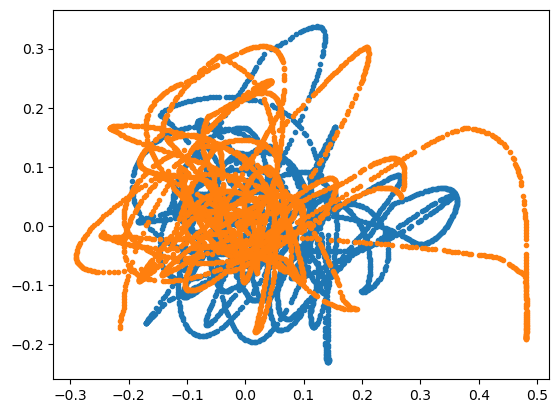

In [81]:
print("The datasets consists of shuffled trajectories")

print(len(flow_xs_train))
flow_xs_train[0].shape

plt.plot(xss_md_train[0][:,0].detach(), xss_md_train[0][:,1].detach(), '.')
plt.plot(xss_md_train[1][:,0].detach(), xss_md_train[1][:,1].detach(), '.')


# 3. -  Inspecting trainings

In [13]:
len(dict_results_adaptive[0]['dict_flows_training'])
len(dict_results_adaptive[0]['dict_flows_training'][4])
print(dict_results_adaptive[0]['dict_flows_training'][4][1].keys())
print(dict_results_adaptive[0]['dict_flows_training'][4][0].keys())
print(len(dict_results_adaptive[0]['dict_flows_training'][4][1]['models']))
print(len(dict_results_adaptive[0]['dict_flows_training'][4][0]['models']))

# for dic in dict_results_adaptive[0]['dict_flows_training']:
# plt.plot(flows_dic[0]['losses'][0])
# plt.plot(flows_dic[0]['losses'][1])

dict_keys(['model', 'losses', 'models', 'grad_norms', 'lr', 'time_epoch', 'time_batch'])
dict_keys(['model', 'losses', 'models', 'grad_norms', 'lr', 'time_epoch', 'time_batch'])
6
6


There is two dictionaries per run: One per isomer.

/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/numpy/core/shape_base.py:65: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  ary = asanyarray(ary)


ValueError: Input could not be cast to an at-least-1D NumPy array

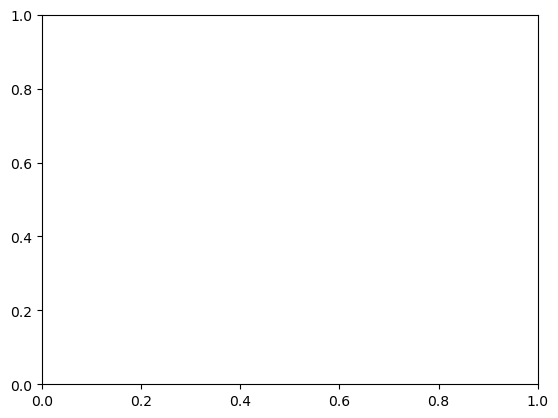

In [14]:
for isomer_id in [0,1]:
    loss = []
    for run in dict_results_adaptive[isomer_id]['dict_flows_training']:
        loss.append(run[0]['losses'])
plt.plot(loss)
loss[0].shape

## 3.2 -  Looking at the participation ratio in face with MLPs 
Still need to check that everything is done within the right framework.

In [24]:
mlps_dic = [load_pickle_file('/'+ f, path=project_path) for f in mlps_files]

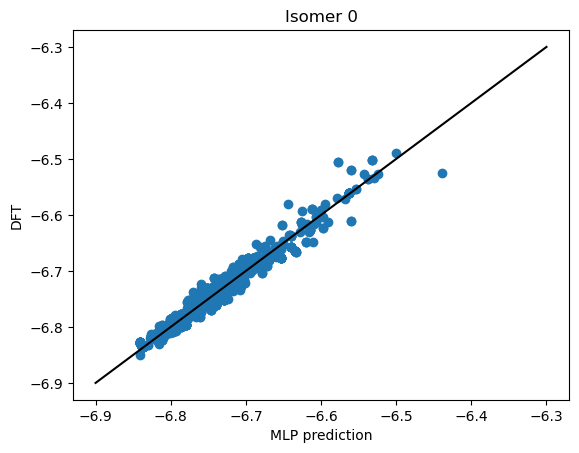

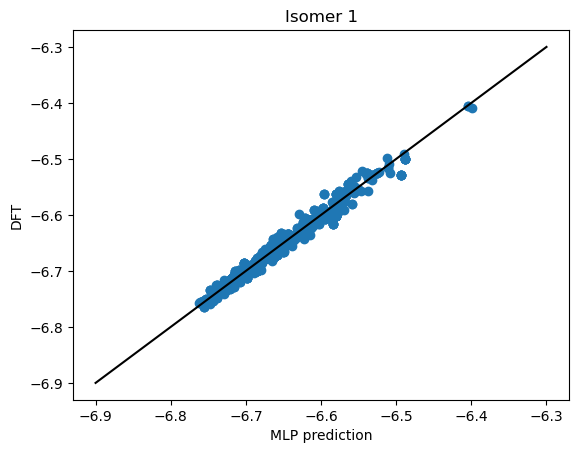

In [54]:
for isomer_id in mode_labels:
    xs_dft = dict_results_adaptive[isomer_id]['mcmc_runs'][isomer_id]['xs_dft']
    us_dft = dict_results_adaptive[isomer_id]['mcmc_runs'][isomer_id]['us_dft']

    plt.figure()
    plt.title('Isomer {:d}'.format(isomer_id))
    plt.scatter(mlps_dic[isomer_id]['model'](xs_dft).detach().view(-1), us_dft, label='DFT')
    plt.plot(np.linspace(-6.9, -6.3, 2), np.linspace(-6.9, -6.3, 2), label='y=x', color='black')
    plt.xlabel('MLP prediction')
    plt.ylabel('DFT')


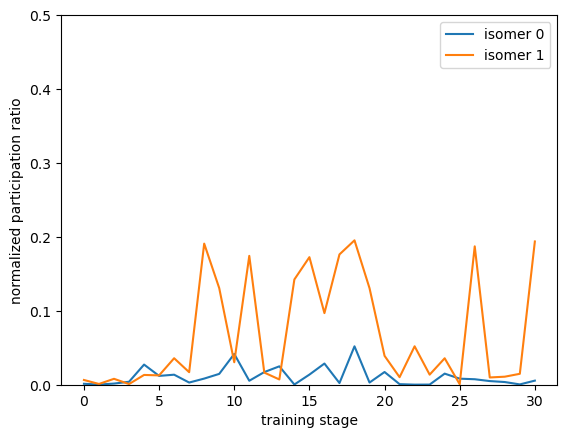

In [55]:
from flonacomldft.utils.diagnostics import get_participation_ratio

mode_labels = [0, 1]
n_prop = 10000
for isomer_id in mode_labels:
    pprs = []
    for run in dict_results_adaptive[isomer_id]['dict_flows_training']:
        flow = run[0]['models'][-1]
        target_log_prob = lambda x: - mlps_dic[isomer_id]['model'](x) / (kb * T)
        ppr = get_participation_ratio(flow, target_log_prob, n_prop)
        pprs.append(ppr.item())
    plt.plot(pprs, label='isomer {:d}'.format(isomer_id))
plt.xlabel('training stage')
plt.ylabel('normalized participation ratio')
plt.ylim(0, 0.5)
# plt.axhline(1, c='k', ls='--')
# plt.yscale('log')
plt.legend()

# 4 - Computing the free energy differences

In [56]:
# target_log_probs = []
# for m in mode_labels:
#     target = lambda x: - mlps[m](x) / (kb * T)
#     target_log_probs.append(target)

target_log_probs = [lambda x: - mlps_dic[isomer_id]['model'](x) / (kb * T) for isomer_id in mode_labels]

## 4.1 - Per isomer test

/Users/marylou/Dropbox/Prof/Experiments/ml-dft/ML-DFT/packages/flonaco-ml-dft/flonacomldft/free_energy_computations.py:40: RuntimeWarning: overflow encountered in exp
  err = np.sqrt(np.var(np.exp(logr_per_sample)) / np.exp(2 * logr)  / n_prop)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/numpy/core/_methods.py:236: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


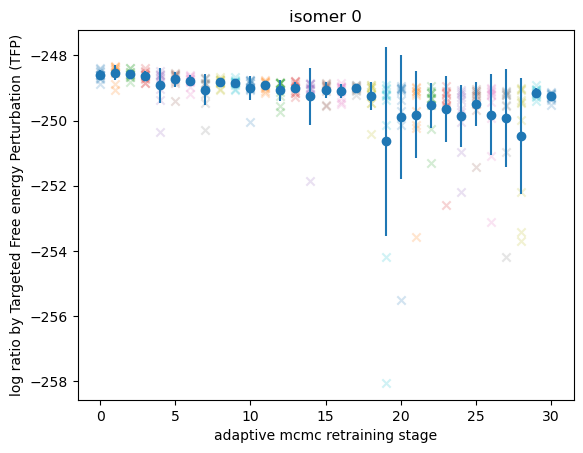

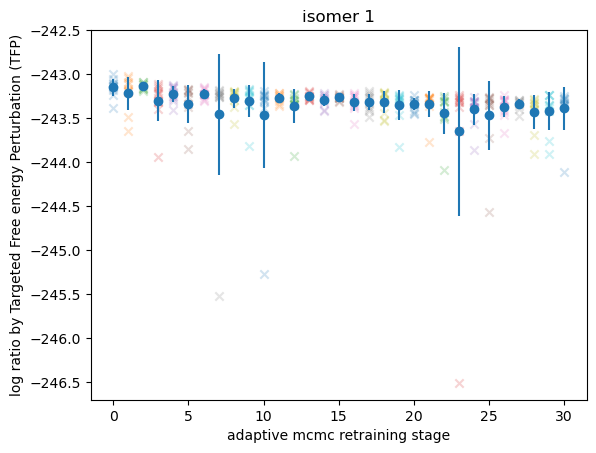

In [107]:
n_prop = 8000

dic_results_TFPs = {}

for isomer_id in mode_labels:

    dic_results_TFPs[isomer_id] = {}
    dic_results_TFPs[isomer_id]['means'] = []
    dic_results_TFPs[isomer_id]['stds'] = []

    target_log_prob = lambda x: - mlps_dic[isomer_id]['model'](x) / (kb * T)
    plt.figure()
    plt.title('isomer {:d}'.format(isomer_id))
    for r,run in enumerate(dict_results_adaptive[isomer_id]['dict_flows_training']):
        flow = run[0]['models'][-1]
        log_ratio_0_TFPs = []
        log_err_0_TFPs = []

        for trial in range(10):
            logr_TFP_0, log_err_TFP_0 = compute_TFP(n_prop, target_log_prob, flow)
            log_ratio_0_TFPs.append(logr_TFP_0)
            log_err_0_TFPs.append(log_err_TFP_0)
        
        dic_results_TFPs[isomer_id][r] = (log_ratio_0_TFPs, log_err_0_TFPs)
        
        plt.scatter(np.ones(len(log_ratio_0_TFPs))*r, log_ratio_0_TFPs, marker='x', alpha=0.2)
        plt.scatter(r, np.array(log_ratio_0_TFPs).mean(), c='k', marker='+')

        dic_results_TFPs[isomer_id]['means'].append(np.array(log_ratio_0_TFPs).mean())
        dic_results_TFPs[isomer_id]['stds'].append(np.array(log_ratio_0_TFPs).std())
    
    plt.errorbar(np.arange(len(dic_results_TFPs[isomer_id]['means'])), dic_results_TFPs[isomer_id]['means'], yerr=dic_results_TFPs[isomer_id]['stds'], fmt='o')
       

    plt.xlabel('adaptive mcmc retraining stage')
    plt.ylabel('log ratio by Targeted Free energy Perturbation (TFP)')

    # print('logr_TFP {:.3e} +/- {:.3e}'.format(np.array(log_ratio_0_TFPs).mean(), np.array(log_ratio_0_TFPs).std()))

/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -1.9669535902266944e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -4.213713566514343e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -7.491201756693044e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -1.9256105190379458e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -5.519120435337754e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylo

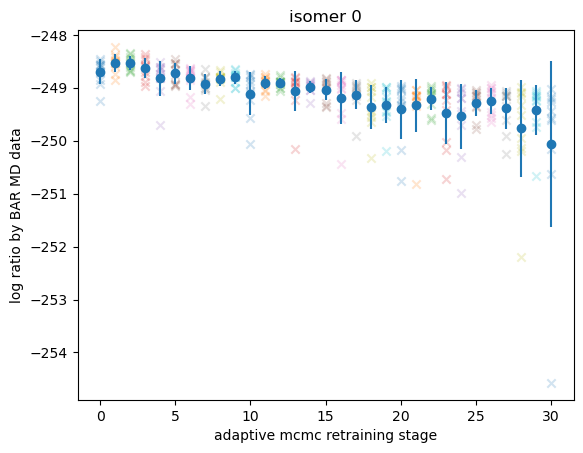

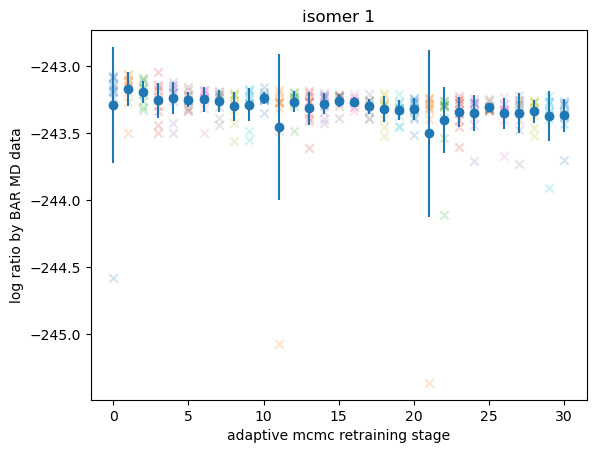

In [105]:
n_prop = 8000

dic_results_BAR_md = {}

for isomer_id in mode_labels:

    dic_results_BAR_md[isomer_id] = {}
    dic_results_BAR_md[isomer_id]['means'] = []
    dic_results_BAR_md[isomer_id]['stds'] = []

    xs = xss_md_train[isomer_id][:, :12]
    target_log_prob = lambda x: - mlps_dic[isomer_id]['model'](x) / (kb * T)
    plt.figure()
    plt.title('isomer {:d}'.format(isomer_id))
    for r,run in enumerate(dict_results_adaptive[isomer_id]['dict_flows_training']):
        flow = run[0]['models'][-1]
        log_ratio_0_BARs = []
        log_err_0_BARs = []

        for trial in range(10):
            logr_BAR_0, log_err_BAR_0 = compute_BAR(xs, target_log_prob, flow, n_prop)
            log_ratio_0_BARs.append(logr_BAR_0)
            log_err_0_BARs.append(log_err_BAR_0)
        
         
        plt.scatter(np.ones(len(log_ratio_0_BARs))*r, log_ratio_0_BARs, marker='x', alpha=0.2)
        plt.scatter(r, np.array(log_ratio_0_BARs).mean(), c='k', marker='+')

        dic_results_BAR_md[isomer_id]['means'].append(np.array(log_ratio_0_BARs).mean())
        dic_results_BAR_md[isomer_id]['stds'].append(np.array(log_ratio_0_BARs).std())
    
    plt.errorbar(np.arange(len(dic_results_BAR_md[isomer_id]['means'])), dic_results_BAR_md[isomer_id]['means'], yerr=dic_results_BAR_md[isomer_id]['stds'], fmt='o')
       

    plt.xlabel('adaptive mcmc retraining stage')
    plt.ylabel('log ratio by BAR MD data')


        # print('logr_BAR {:.3e} +/- {:.3e}'.format(np.array(log_ratio_0_BARs).mean(), np.array(log_ratio_0_BARs).std()))

In [101]:


xs.shape

torch.Size([30000, 12])

/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 2.2509854602503765e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.8089400555254542e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 5.207203059853782e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 2.4125333197844157e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -4.621809836180546e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/a

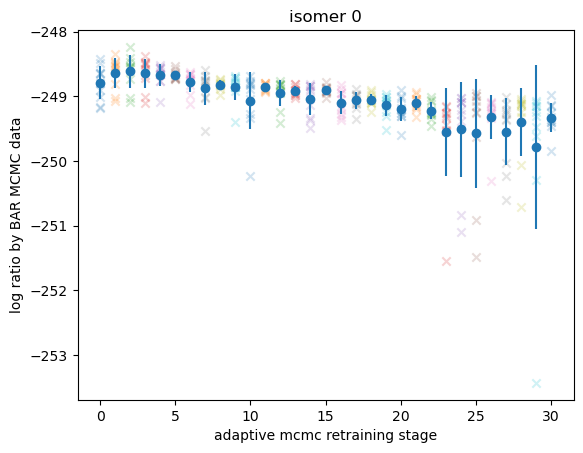

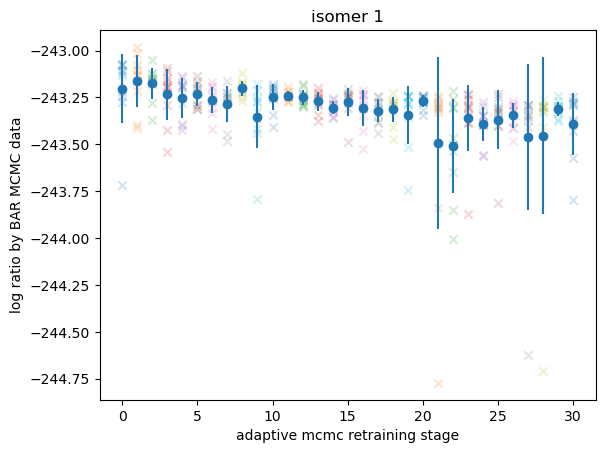

In [104]:
n_prop = 8000

dic_results_BAR_mcmc = {}

for isomer_id in mode_labels:
    dic_results_BAR_mcmc[isomer_id] = {}
    dic_results_BAR_mcmc[isomer_id]['means'] = []
    dic_results_BAR_mcmc[isomer_id]['stds'] = []

    xs = torch.cat(dict_results_adaptive[isomer_id]['xs']).view(-1, 12)
    target_log_prob = lambda x: - mlps_dic[isomer_id]['model'](x) / (kb * T)
    plt.figure()
    plt.title('isomer {:d}'.format(isomer_id))
    for r,run in enumerate(dict_results_adaptive[isomer_id]['dict_flows_training']):
        flow = run[0]['models'][-1]
        log_ratio_0_BARs = []
        log_err_0_BARs = []

        for trial in range(10):
            logr_BAR_0, log_err_BAR_0 = compute_BAR(xs, target_log_prob, flow, n_prop)
            log_ratio_0_BARs.append(logr_BAR_0)
            log_err_0_BARs.append(log_err_BAR_0)
        
        plt.scatter(np.ones(len(log_ratio_0_BARs))*r, log_ratio_0_BARs, marker='x', alpha=0.2)
        plt.scatter(r, np.array(log_ratio_0_BARs).mean(), c='k', marker='+')

        dic_results_BAR_mcmc[isomer_id]['means'].append(np.array(log_ratio_0_BARs).mean())
        dic_results_BAR_mcmc[isomer_id]['stds'].append(np.array(log_ratio_0_BARs).std())
    
    plt.errorbar(np.arange(len(dic_results_BAR_mcmc[isomer_id]['means'])), dic_results_BAR_mcmc[isomer_id]['means'], yerr=dic_results_BAR_mcmc[isomer_id]['stds'], fmt='o')
   
    plt.xlabel('adaptive mcmc retraining stage')
    plt.ylabel('log ratio by BAR MCMC data')

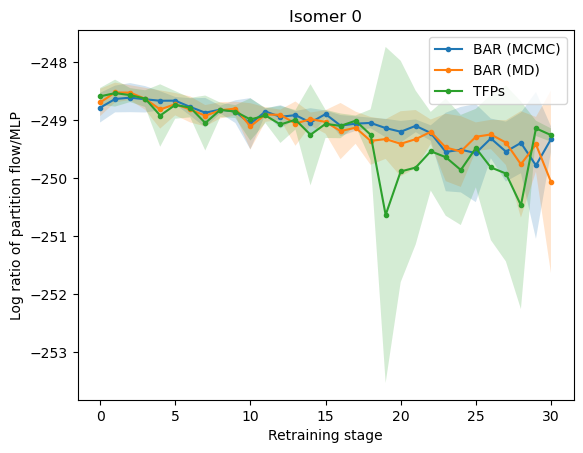

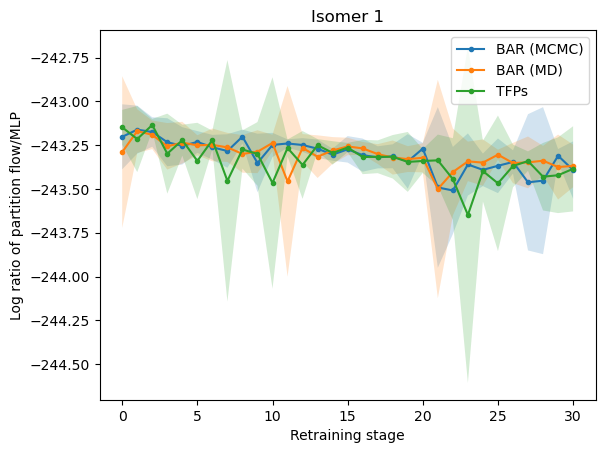

In [113]:
for isomer_id in mode_labels:
    plt.figure()
    plt.title('Isomer {}'.format(isomer_id))
    
    means = np.array(dic_results_BAR_mcmc[isomer_id]['means'])
    stds = np.array(dic_results_BAR_mcmc[isomer_id]['stds'])
    plt.plot(np.arange(len(means)), means, '.-', label='BAR (MCMC)')
    plt.fill_between(np.arange(len(means)), means - stds, means + stds, alpha=0.2)


    means = np.array(dic_results_BAR_md[isomer_id]['means'])
    stds = np.array(dic_results_BAR_md[isomer_id]['stds'])
    plt.plot(np.arange(len(means)), means, '.-', label='BAR (MD)')
    plt.fill_between(np.arange(len(means)), means - stds, means + stds, alpha=0.2)

    means = np.array(dic_results_TFPs[isomer_id]['means'])
    stds = np.array(dic_results_TFPs[isomer_id]['stds'])
    plt.plot(np.arange(len(means)), means, '.-', label='TFPs')
    plt.fill_between(np.arange(len(means)), means - stds, means + stds, alpha=0.2)

    plt.legend()
    plt.xlabel('Retraining stage')
    plt.ylabel('Log ratio of partition flow/MLP')
    
    # plt.errorbar(np.arange(len(dic_results_BAR_mcmc[isomer_id]['means'])), dic_results_BAR_mcmc[isomer_id]['means'], yerr=dic_results_BAR_mcmc[isomer_id]['stds'], fmt='.-')
    # plt.fill_between(np.arange(len(dic_results_BAR_mcmc[isomer_id]['means'])), dic_results_BAR_mcmc[isomer_id]['means'] - dic_results_BAR_mcmc[isomer_id]['stds'], dic_results_BAR_mcmc[isomer_id]['means'] + dic_results_BAR_mcmc[isomer_id]['stds'], alpha=0.2)
    # plt.errorbar(np.arange(len(dic_results_BAR_md[isomer_id]['means'])), dic_results_BAR_md[isomer_id]['means'], yerr=dic_results_BAR_md[isomer_id]['stds'], fmt='.-')
    # plt.errorbar(np.arange(len(dic_results_TFPs[isomer_id]['means'])), dic_results_TFPs[isomer_id]['means'], yerr=dic_results_TFPs[isomer_id]['stds'], fmt='.-')


In [ ]:
TODO: 
- improve the errror estimation
- compute ratios of mode populations
